In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean visualization
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

In [2]:
np.random.seed(42)
n_samples = 1000

data = {
    'Applicant_Age': np.random.normal(38, 10, n_samples).astype(int),
    'Annual_Income': np.random.exponential(scale=50000, size=n_samples) + 20000,
    'Credit_Score': np.random.randint(300, 850, n_samples),
    'Skill_Wallet_Balance': np.random.exponential(scale=500, size=n_samples),
    'Employment_Status': np.random.choice(['Employed', 'Self-Employed', 'Freelancer', 'Unemployed'], size=n_samples, p=[0.6, 0.2, 0.15, 0.05]),
    'Education_Level': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], size=n_samples, p=[0.2, 0.5, 0.2, 0.1]),
    'Approval_Status': np.random.choice([0, 1], size=n_samples, p=[0.4, 0.6])
}

df = pd.DataFrame(data)

# Introduce a small percentage of missing values to simulate a real data scenario
df.loc[df.sample(frac=0.03).index, 'Credit_Score'] = np.nan

print("--- Dataset Overview ---")
print(df.info())
print("\n")

--- Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Applicant_Age         1000 non-null   int64  
 1   Annual_Income         1000 non-null   float64
 2   Credit_Score          970 non-null    float64
 3   Skill_Wallet_Balance  1000 non-null   float64
 4   Employment_Status     1000 non-null   object 
 5   Education_Level       1000 non-null   object 
 6   Approval_Status       1000 non-null   int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 54.8+ KB
None




In [3]:
print("--- Missing Values Count ---")
print(df.isnull().sum())
print("\n")

print("--- Unique Values (Cardinality) ---")
print(df.nunique())
print("\n")

--- Missing Values Count ---
Applicant_Age            0
Annual_Income            0
Credit_Score            30
Skill_Wallet_Balance     0
Employment_Status        0
Education_Level          0
Approval_Status          0
dtype: int64


--- Unique Values (Cardinality) ---
Applicant_Age             57
Annual_Income           1000
Credit_Score             445
Skill_Wallet_Balance    1000
Employment_Status          4
Education_Level            4
Approval_Status            2
dtype: int64




--- Summary Statistics (Numerical Features) ---
                       count          mean           std           min  \
Applicant_Age         1000.0     37.674000      9.797741      5.000000   
Annual_Income         1000.0  70399.296685  50149.425449  20161.172668   
Credit_Score           970.0    573.588660    159.689860    300.000000   
Skill_Wallet_Balance  1000.0    486.879189    494.022640      0.015360   

                               25%           50%           75%            max  
Applicant_Age            31.000000     38.000000     44.000000      76.000000  
Annual_Income         34197.725844  56296.561034  88584.212653  392086.145485  
Credit_Score            431.500000    575.000000    713.000000     849.000000  
Skill_Wallet_Balance    138.205971    339.320792    668.861443    3861.764761  


--- Distribution Shape (Skewness & Kurtosis) ---
Applicant_Age          -> Skewness: 0.11 | Kurtosis: 0.06
Annual_Income          -> Skewness: 1.98 | Kurtosis: 5.41
Credit_Score  

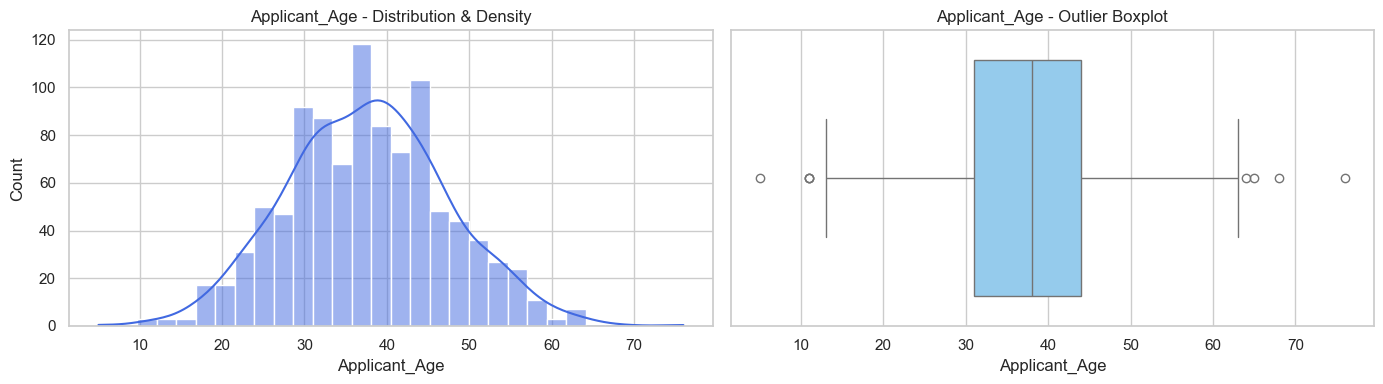

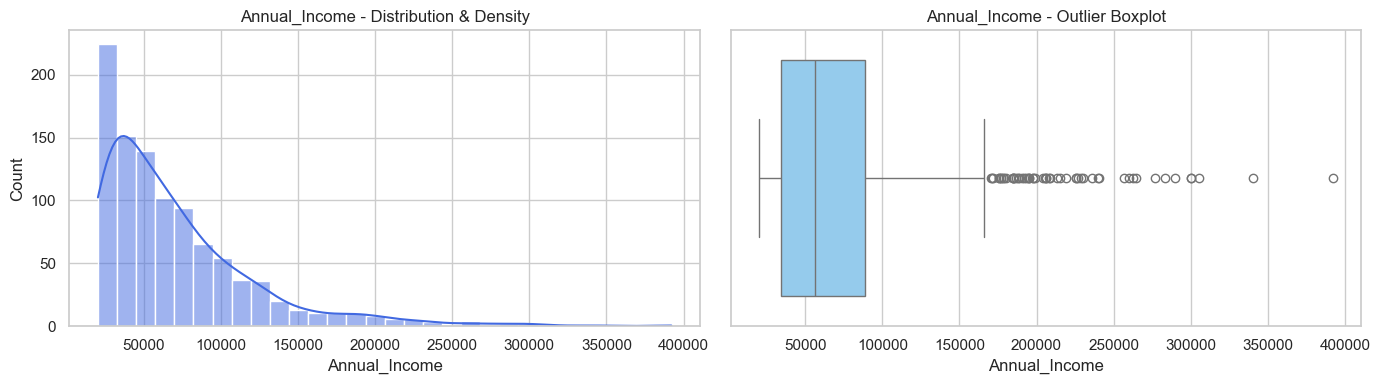

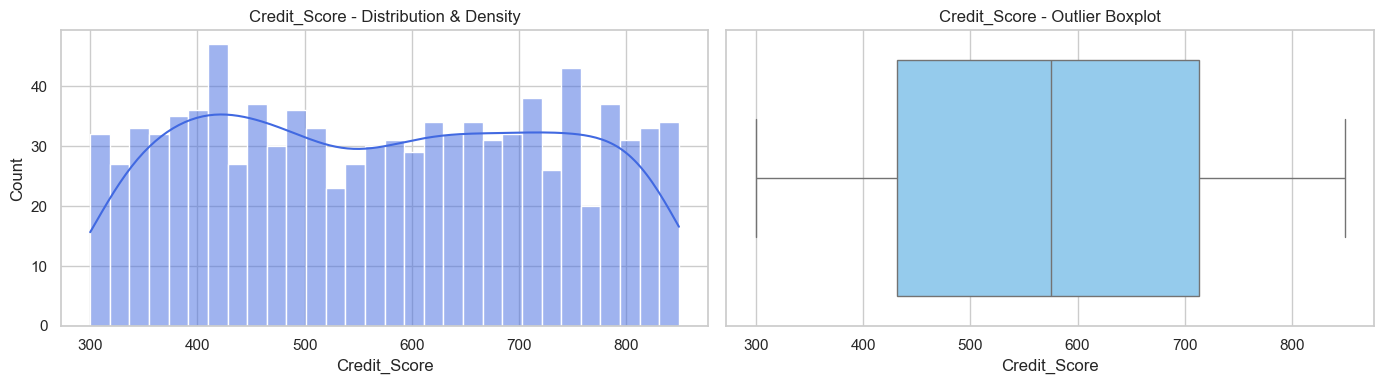

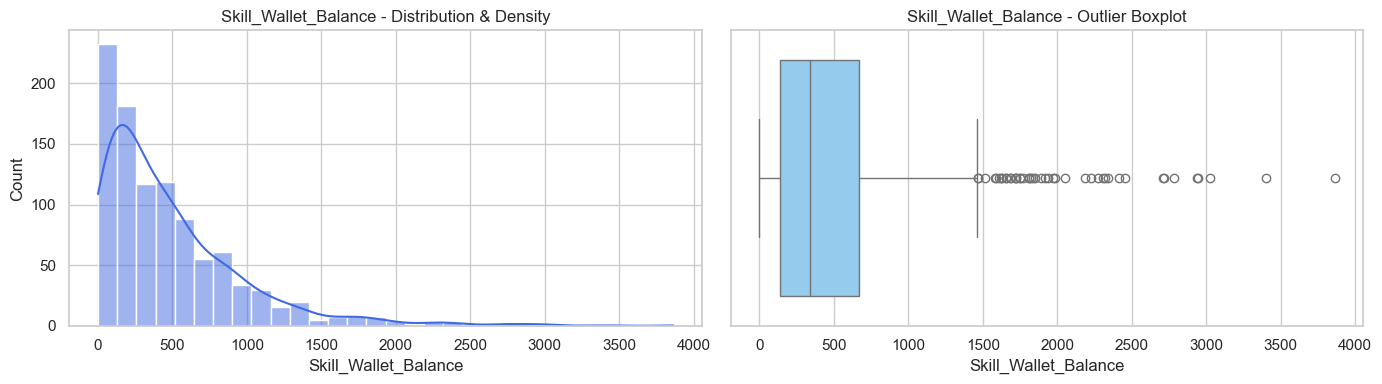

In [4]:
num_cols = ['Applicant_Age', 'Annual_Income', 'Credit_Score', 'Skill_Wallet_Balance']

print("--- Summary Statistics (Numerical Features) ---")
print(df[num_cols].describe().T)
print("\n")

print("--- Distribution Shape (Skewness & Kurtosis) ---")
for col in num_cols:
    print(f"{col:<22} -> Skewness: {df[col].skew():.2f} | Kurtosis: {df[col].kurt():.2f}")
print("\n")

# Plot Histograms and Boxplots for all numerical variables
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histogram + KDE (shows distribution profile)
    sns.histplot(df[col], kde=True, ax=axes[0], color='royalblue', bins=30)
    axes[0].set_title(f'{col} - Distribution & Density')
    
    # Boxplot (shows outliers clearly)
    sns.boxplot(x=df[col], ax=axes[1], color='lightskyblue')
    axes[1].set_title(f'{col} - Outlier Boxplot')
    
    plt.tight_layout()
    plt.show()

--- Frequency Distribution: Employment_Status ---
                   Count  Percentage (%)
Employment_Status                       
Employed             620            62.0
Self-Employed        183            18.3
Freelancer           149            14.9
Unemployed            48             4.8




C:\Users\nandi\AppData\Local\Temp\ipykernel_17788\3154443582.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')


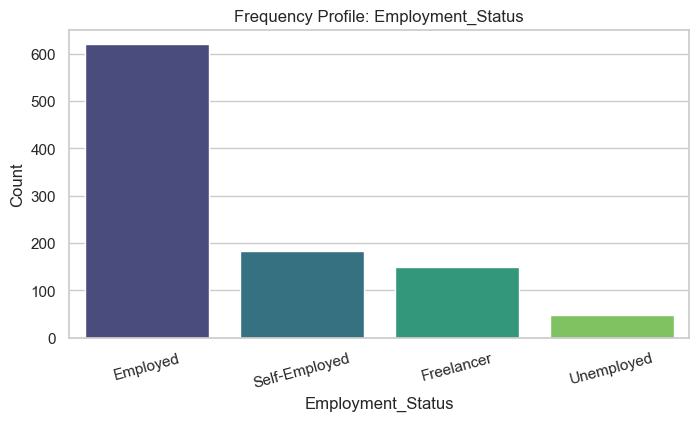

--- Frequency Distribution: Education_Level ---
                 Count  Percentage (%)
Education_Level                       
Bachelor           494            49.4
High School        212            21.2
Master             189            18.9
PhD                105            10.5




C:\Users\nandi\AppData\Local\Temp\ipykernel_17788\3154443582.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')


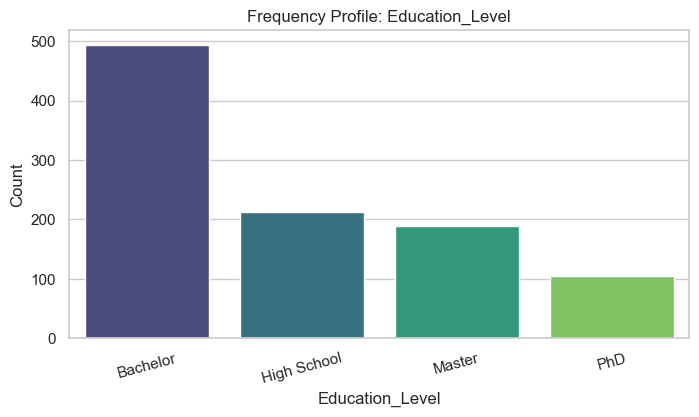

In [6]:
cat_cols = ['Employment_Status', 'Education_Level']

for col in cat_cols:
    print(f"--- Frequency Distribution: {col} ---")
    freq_df = pd.DataFrame({
        'Count': df[col].value_counts(),
        'Percentage (%)': df[col].value_counts(normalize=True) * 100
    })
    print(freq_df.round(2))
    print("\n")
    
    # Plot Category Prevalence
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Frequency Profile: {col}')
    plt.ylabel('Count')
    plt.xlabel(col)
    plt.xticks(rotation=15)
    plt.show()

--- Target Imbalance (Approval_Status) ---
Rejected (0): 39.30%
Approved (1): 60.70%




C:\Users\nandi\AppData\Local\Temp\ipykernel_17788\2267641777.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Approval_Status', palette='pastel')


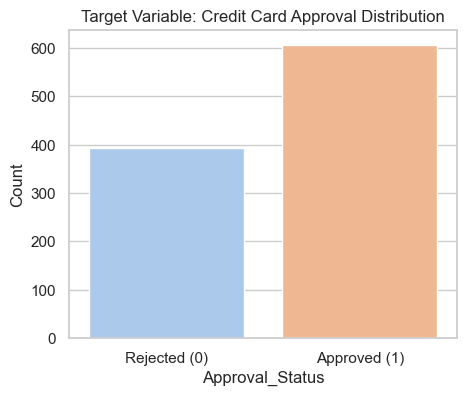

In [7]:
print("--- Target Imbalance (Approval_Status) ---")
target_freq = df['Approval_Status'].value_counts(normalize=True) * 100
print(f"Rejected (0): {target_freq[0]:.2f}%")
print(f"Approved (1): {target_freq[1]:.2f}%")
print("\n")

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Approval_Status', palette='pastel')
plt.title('Target Variable: Credit Card Approval Distribution')
plt.xticks(ticks=[0, 1], labels=['Rejected (0)', 'Approved (1)'])
plt.ylabel('Count')
plt.show()